# 08 · Coincident frequency

Start with a tractable sum, then follow the Waimea/Makaweli conditional stage-frequency example.

**Execution:** the default walkthrough reads checked saved app results, so it needs no live download or MCMC run.
Install this repository and the shared `bestfit-plots` package as described in the [README](../README.md).
To repeat an analysis, first build the pinned .NET runtime, set `RUN_ANALYSES = True`, and run the notebook in a fresh kernel.
The rerun retains the source priors, seeds, sampling settings and probability ordinates; receipts are saved under `output/reruns/`.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import json
import pandas as pd
from IPython.display import display
from bestfit_examples.project_data import load_project
from bestfit_examples.data import input_inventory, series_inventory
from bestfit_examples.results import saved_case
from bestfit_examples.presentation import (case_metrics, case_provenance, compare_frequency,
    composite_weights, trend_ownership, uncertain_observations)
%matplotlib inline
RUN_ANALYSES = False  # True: rerun the saved analysis and its dependencies at full original settings.

## Sum of two correlated Normals
For Z=X+Y, the analytic mean is μX+μY and the variance is σX²+σY²+2ρσXσY.
The app provides synthetic cases at ρ=-0.5, 0 and +0.5. This control makes the effect of dependence visible before using a nonlinear response surface.
The chart places response on a **linear** vertical axis and AEP on the horizontal probability axis; its uncertainty bounds are horizontal at fixed response.
These are **Simulated Proof** cases. Their named univariate marginals and bivariate copula are upstream dependencies of each CFA result.

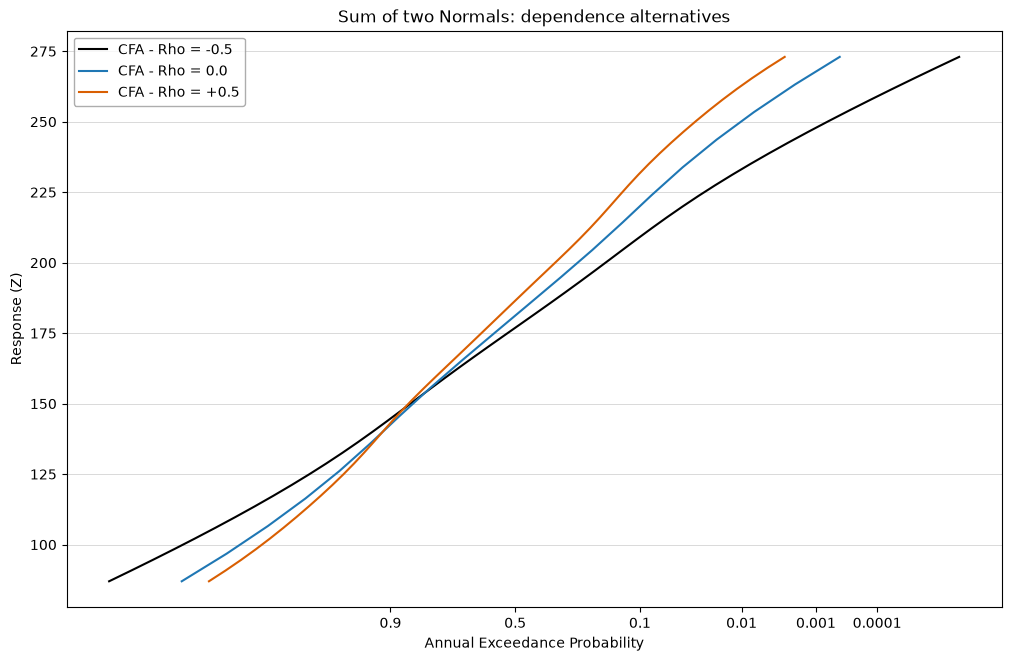

,Setting,Saved choice
0,Analysis,CoincidentFrequencyAnalysis
1,InputData,X+Y Data - Rho = 0.0
2,Model.CopulaType,Normal
3,Model.CopulaEstimationMethod,InferenceFromMargins
4,Model.UseDefaultFlatPriors,True
5,Dependencies,BivariateAnalysis


,Analysis,Response,Bivariate dependency,X ordinates,Y ordinates,Response cells,Output bins
0,CFA - Rho = -0.5,X+Y Data - Rho = -0.5,Normal Copula - Rho = -0.5,7,7,49,50
1,CFA - Rho = 0.0,X+Y Data - Rho = 0.0,Normal Copula - Rho = 0.0,7,7,49,20
2,CFA - Rho = +0.5,X+Y Data - Rho = +0.5,Normal Copula - Rho =+0.5,7,7,49,50


,name,fitted_rho,response_is_x_plus_y,configured_number_of_bins,max_absolute_aep_error
0,CFA - Rho = +0.5,0.398219,True,50,0.008047
1,CFA - Rho = -0.5,-0.454016,True,50,0.004589
2,CFA - Rho = 0.0,0.088551,True,20,0.005251


,Analysis,Origin,Source,Runtime,Settings,Receipt / result
0,CFA - Rho = -0.5,saved-app,sha256:dc63d9466446,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
1,CFA - Rho = 0.0,saved-app,sha256:dc63d9466446,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
2,CFA - Rho = +0.5,saved-app,sha256:dc63d9466446,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt


In [2]:
PROJECT = "sum-two-normals"
names = ["CFA - Rho = -0.5", "CFA - Rho = 0.0", "CFA - Rho = +0.5"]
cases = [saved_case(PROJECT, name, run=RUN_ANALYSES) for name in names]
compare_frequency(cases, "Sum of two Normals: dependence alternatives")
display(cases[1].settings)
cfa_project = load_project(PROJECT)
cfa_rows = {row["Name"]: row for row in cfa_project["tables"]["<Coincident Frequency>"]["rows"]}
display(pd.DataFrame([{
    "Analysis": name,
    "Response": row["InputData"],
    "Bivariate dependency": row["BivariateAnalysis"],
    "X ordinates": len(row["XValues"].split(",")),
    "Y ordinates": len(row["YValues"].split(",")),
    "Response cells": len(row["BivariateResponse"].split(",")),
    "Output bins": int(row["NumberOfBins"]),
} for name in names for row in [cfa_rows[name]]]))
checks = json.loads((ROOT / "validation/source-checks.json").read_text(encoding="utf-8"))
display(pd.DataFrame(checks["sum_two_normals"])[["name", "fitted_rho", "response_is_x_plus_y",
                                                "configured_number_of_bins", "max_absolute_aep_error"]])
display(case_provenance(cases))

## Waimea and Makaweli
Use `CFA - Normal - Conditional`, its saved conditional Normal copula, and its named marginal dependencies.
The conditional Makaweli input represents values associated with Waimea events. Pairing two independently extracted annual maxima would define a different event population.
The saved response surface and ordinates produce the stage-frequency result; they are retained rather than replaced by an invented sum-of-flows calculation.
The selected CFA has no observed response input attached: its frozen `InputData` field is blank.

,Setting,Saved choice
0,Analysis,CoincidentFrequencyAnalysis
1,Model.CopulaType,Normal
2,Model.CopulaEstimationMethod,InferenceFromMargins
3,Model.UseDefaultFlatPriors,True
4,Dependencies,BivariateAnalysis


,Bivariate analysis,Number of bins,X ordinates,Y ordinates,Response cells,Response range (ft),Observed response input
0,Normal Copula - Conditional,50,10,5,50,7.14–28.15,None attached


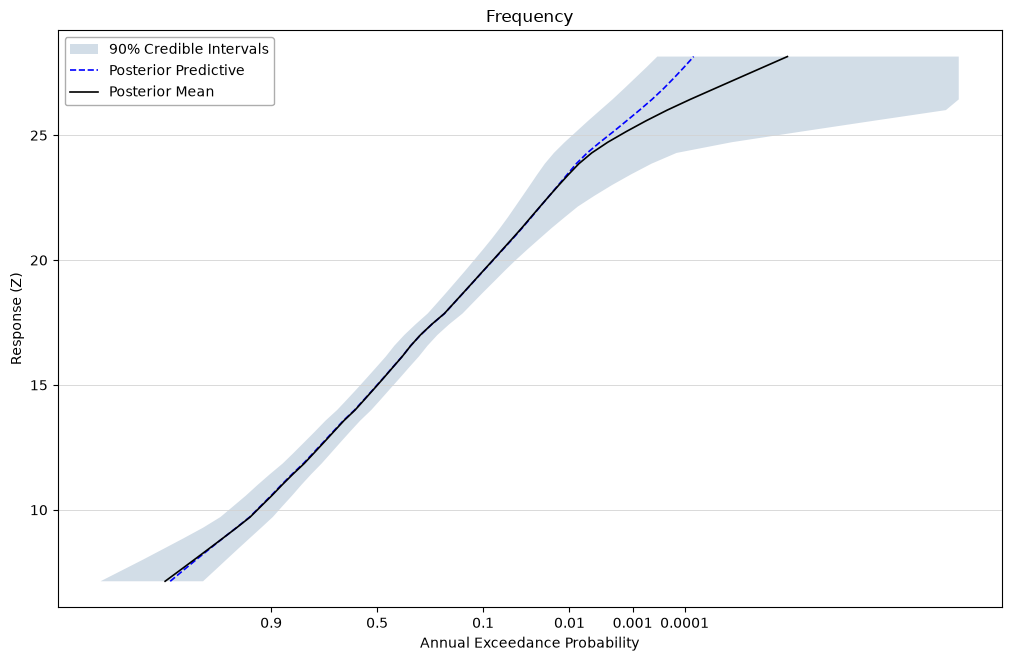

,Input,Unit,Method,Exact,Uncertain,Interval,Threshold,Flagged low floods
0,16031000_Waimea_Peaks,Annual Peak Flow (cfs),Manual,64,0,0,2,3
1,16036000_Makaweli_Peaks,Value,Manual,75,0,0,0,0
2,16036000_Makaweli_Conditional_Peaks,Value,Manual,54,0,0,0,0
3,Simulated Proof,Value,Manual,10000,0,0,0,0


,Analysis,Origin,Source,Runtime,Settings,Receipt / result
0,CFA - Normal - Conditional,saved-app,sha256:b05ed96b6ee4,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt


In [3]:
waimea = saved_case("waimea-river-stage-frequency", "CFA - Normal - Conditional", run=RUN_ANALYSES)
display(waimea.settings)
waimea_project = load_project("waimea-river-stage-frequency")
waimea_rows = waimea_project["tables"]["<Coincident Frequency>"]["rows"]
waimea_row = next(row for row in waimea_rows if row["Name"] == "CFA - Normal - Conditional")
waimea_x = [float(value) for value in waimea_row["XValues"].split(",")]
waimea_y = [float(value) for value in waimea_row["YValues"].split(",")]
waimea_response = [float(value) for value in waimea_row["BivariateResponse"].split(",")]
assert len(waimea_response) == len(waimea_x) * len(waimea_y)
display(pd.DataFrame([{
    "Bivariate analysis": waimea_row["BivariateAnalysis"],
    "Number of bins": int(waimea_row["NumberOfBins"]),
    "X ordinates": len(waimea_x),
    "Y ordinates": len(waimea_y),
    "Response cells": len(waimea_response),
    "Response range (ft)": f"{min(waimea_response):.2f}–{max(waimea_response):.2f}",
    "Observed response input": waimea_row["InputData"] or "None attached",
}]))
waimea.show("frequency")
display(input_inventory(waimea_project))
display(case_provenance([waimea]))

**Interpretation:** the case names give nominal generating correlations; the table uses fitted correlations. The analytic check verifies every saved response cell is X+Y and compares the closed-form Gaussian survival with the saved app curve on its finite grid, reporting errors without changing grid settings. Distinguish marginal/dependence uncertainty from the specified response model; Waimea answers its conditional stage-response question.